# GRU Model for Text Classification

This notebook handles the entire pipeline for training a GRU model on text data:
1. Data loading and preprocessing
2. Text tokenization and sequence creation
3. Word embeddings
4. Hyperparameter tuning
5. Model training and evaluation
6. Model saving


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, initializers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import re
import string
import nltk
from nltk.tokenize import word_tokenize
import keras_tuner as kt
import os

nltk.download('punkt', quiet=True)

np.random.seed(2025)
tf.random.set_seed(2025)


2025-03-27 19:16:53.272096: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-27 19:16:53.285545: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743103013.303483  147199 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743103013.309358  147199 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-27 19:16:53.328926: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## Data Preparation

In [2]:
print("Loading dataset...")
df = pd.read_csv("../../datasets/custom_dataset.csv", sep="\t")
print(f"Dataset shape: {df.shape}")
df.head()


Loading dataset...
Dataset shape: (5437, 2)


,Text,Label
0,"In mechanics, a variable-mass system is a coll...",Human
1,Variable-mass systems in fluids involve object...,AI
2,"Geomechanics (from the Greek γεός, i.e. prefix...",Human
3,Geomechanics studies the mechanical behavior o...,AI
4,Microscale chemistry (often referred to as sma...,Human


In [3]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    
    text = re.sub(r"https?://\S+|www\.\S+|\S+@\S+\.\S+", "", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df['cleaned_text'] = df['Text'].apply(clean_text)

df[['Text', 'cleaned_text']].sample(5)

labels = df['Label'].apply(lambda x: 0 if x == 'Human' else 1).values

print(f"Label distribution: {pd.Series(labels).value_counts().to_dict()}")

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['cleaned_text'].values, labels, test_size=0.3, random_state=2025, stratify=labels
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=2025, stratify=temp_labels
)

print(f"Training set: {len(train_texts)} samples")
print(f"Validation set: {len(val_texts)} samples")
print(f"Test set: {len(test_texts)} samples")


Label distribution: {1: 3461, 0: 1976}
Training set: 3805 samples
Validation set: 816 samples
Test set: 816 samples


In [4]:
max_words = 2500
max_seq_length = 128

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

vocab_size = min(max_words, len(tokenizer.word_index) + 1)
print(f"Vocabulary size: {vocab_size}")

train_sequences = tokenizer.texts_to_sequences(train_texts)
val_sequences = tokenizer.texts_to_sequences(val_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

train_padded = pad_sequences(train_sequences, maxlen=max_seq_length, padding='post', truncating='post')
val_padded = pad_sequences(val_sequences, maxlen=max_seq_length, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_seq_length, padding='post', truncating='post')

print(f"Training sequences shape: {train_padded.shape}")
print(f"Validation sequences shape: {val_padded.shape}")
print(f"Test sequences shape: {test_padded.shape}")


Vocabulary size: 2500
Training sequences shape: (3805, 128)
Validation sequences shape: (816, 128)
Test sequences shape: (816, 128)


## Model Development

In [5]:
def build_gru_model(hp):
    model = keras.Sequential()
    
    embedding_dim = hp.Int('embedding_dim', 64, 256, step=64)
    model.add(layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_seq_length,
        embeddings_initializer=initializers.GlorotUniform(seed=2025)
    ))
    
    model.add(layers.SpatialDropout1D(
        hp.Float('spatial_dropout', 0.1, 0.5, step=0.1)
    ))
    
    model.add(layers.GRU(
        units=hp.Int('gru_units_1', 8, 64, step=8),
        return_sequences=True,
        dropout=hp.Float('dropout_1', 0.1, 0.5, step=0.1),
        recurrent_dropout=hp.Float('recurrent_dropout_1', 0.1, 0.5, step=0.1),
        activation='tanh'
    ))
    
    model.add(layers.GRU(
        units=hp.Int('gru_units_2', 8, 64, step=8),
        dropout=hp.Float('dropout_2', 0.1, 0.5, step=0.1),
        recurrent_dropout=hp.Float('recurrent_dropout_2', 0.1, 0.5, step=0.1),
        activation='tanh'
    ))
    
    model.add(layers.Dense(1, activation='sigmoid'))
    
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
        ),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(), keras.metrics.Precision(), keras.metrics.Recall()]
    )
    
    return model

tuner = kt.Hyperband(
    build_gru_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='../../tuner_results',
    project_name='gru_model'
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True
)

tuner.search(
    train_padded, train_labels,
    epochs=25,
    validation_data=(val_padded, val_labels),
    callbacks=[early_stopping]
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best hyperparameters: {best_hps.values}")


Trial 30 Complete [00h 01m 18s]
val_accuracy: 0.9816176295280457

Best val_accuracy So Far: 0.9926470518112183
Total elapsed time: 00h 21m 45s
Best hyperparameters: {'embedding_dim': 64, 'spatial_dropout': 0.30000000000000004, 'gru_units_1': 56, 'dropout_1': 0.2, 'recurrent_dropout_1': 0.30000000000000004, 'gru_units_2': 8, 'dropout_2': 0.1, 'recurrent_dropout_2': 0.2, 'learning_rate': 0.006056847520266454, 'tuner/epochs': 4, 'tuner/initial_epoch': 2, 'tuner/bracket': 2, 'tuner/round': 1, 'tuner/trial_id': '0007'}


Epoch 1/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.6307 - auc_3: 0.5186 - loss: 0.6570 - precision_3: 0.6446 - recall_3: 0.9553

119/119 ━━━━━━━━━━━━━━━━━━━━ 28s 176ms/step - accuracy: 0.6309 - auc_3: 0.5196 - loss: 0.6567 - precision_3: 0.6448 - recall_3: 0.9553 - val_accuracy: 0.7108 - val_auc_3: 0.9162 - val_loss: 0.5351 - val_precision_3: 0.9522 - val_recall_3: 0.5750 - learning_rate: 0.0061
Epoch 2/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.8720 - auc_3: 0.8900 - loss: 0.3636 - precision_3: 0.8998 - recall_3: 0.9009

119/119 ━━━━━━━━━━━━━━━━━━━━ 20s 169ms/step - accuracy: 0.8723 - auc_3: 0.8904 - loss: 0.3628 - precision_3: 0.8999 - recall_3: 0.9012 - val_accuracy: 0.9706 - val_auc_3: 0.9979 - val_loss: 0.1029 - val_precision_3: 0.9593 - val_recall_3: 0.9962 - learning_rate: 0.0061
Epoch 3/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9778 - auc_3: 0.9955 - loss: 0.0769 - precision_3: 0.9820 - recall_3: 0.9832

119/119 ━━━━━━━━━━━━━━━━━━━━ 20s 168ms/step - accuracy: 0.9778 - auc_3: 0.9955 - loss: 0.0768 - precision_3: 0.9820 - recall_3: 0.9832 - val_accuracy: 0.9865 - val_auc_3: 0.9972 - val_loss: 0.0524 - val_precision_3: 0.9848 - val_recall_3: 0.9942 - learning_rate: 0.0061
Epoch 4/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9948 - auc_3: 0.9993 - loss: 0.0247 - precision_3: 0.9955 - recall_3: 0.9962

119/119 ━━━━━━━━━━━━━━━━━━━━ 20s 169ms/step - accuracy: 0.9948 - auc_3: 0.9992 - loss: 0.0248 - precision_3: 0.9955 - recall_3: 0.9962 - val_accuracy: 0.9865 - val_auc_3: 0.9984 - val_loss: 0.0395 - val_precision_3: 0.9885 - val_recall_3: 0.9904 - learning_rate: 0.0061
Epoch 5/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 21s 175ms/step - accuracy: 0.9931 - auc_3: 0.9998 - loss: 0.0204 - precision_3: 0.9927 - recall_3: 0.9965 - val_accuracy: 0.9718 - val_auc_3: 0.9955 - val_loss: 0.0823 - val_precision_3: 0.9628 - val_recall_3: 0.9942 - learning_rate: 0.0061
Epoch 6/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 20s 164ms/step - accuracy: 0.9959 - auc_3: 0.9999 - loss: 0.0110 - precision_3: 0.9960 - recall_3: 0.9976 - val_accuracy: 0.9853 - val_auc_3: 0.9974 - val_loss: 0.0524 - val_precision_3: 0.9866 - val_recall_3: 0.9904 - learning_rate: 0.0061
Epoch 7/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 19s 157ms/step - accuracy: 0.9978 - auc_3: 1.0000 - loss: 0.0078 - precision_3: 0.9983 - recall_3: 0.9983 - val_accuracy: 0.9804

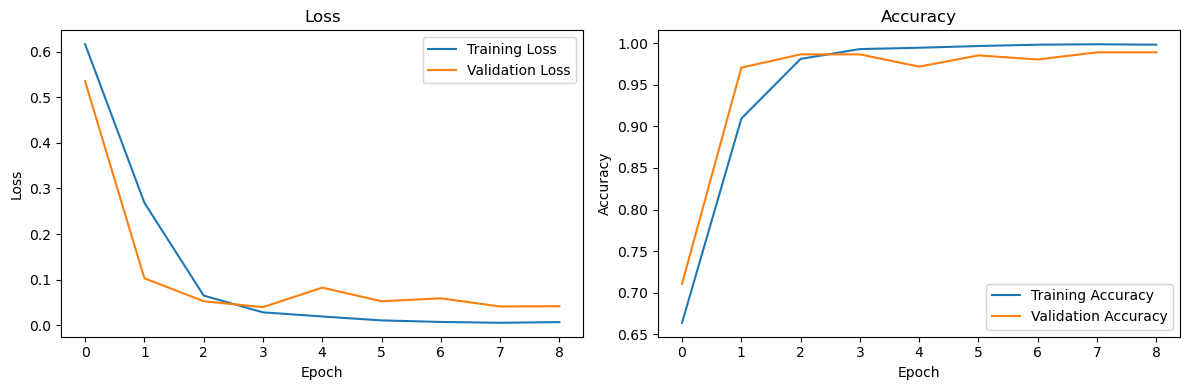

In [6]:
model = tuner.hypermodel.build(best_hps)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('../../trained_models/tensorflow/gru_model.h5', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

history = model.fit(
    train_padded, train_labels,
    validation_data=(val_padded, val_labels),
    epochs=25,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


## Model Evaluation

26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9881 - auc_3: 0.9993 - loss: 0.0364 - precision_3: 0.9924 - recall_3: 0.9887
Test accuracy: 0.9926
Test AUC: 0.9995
Test precision: 0.9942
Test recall: 0.9942
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step


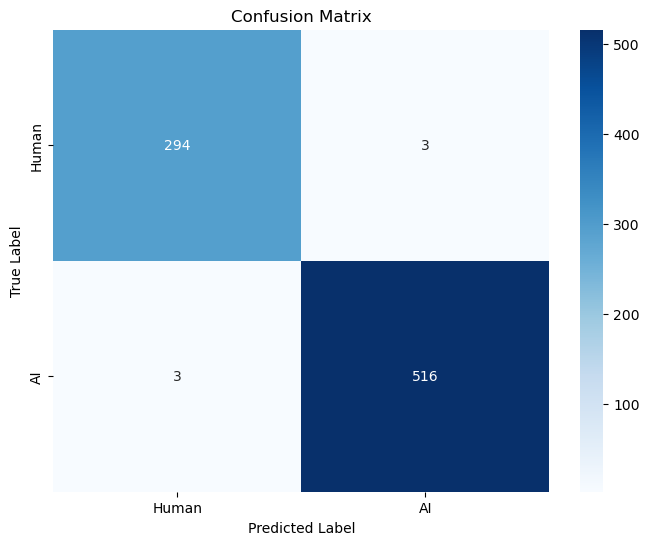

Classification Report:
              precision    recall  f1-score   support

       Human       0.99      0.99      0.99       297
          AI       0.99      0.99      0.99       519

    accuracy                           0.99       816
   macro avg       0.99      0.99      0.99       816
weighted avg       0.99      0.99      0.99       816



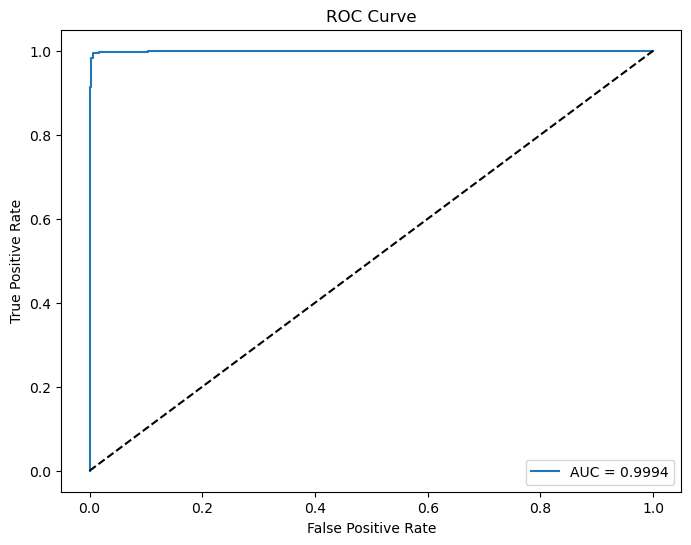

In [7]:
model = keras.models.load_model('../../trained_models/tensorflow/gru_model.h5')

test_loss, test_acc, test_auc, test_precision, test_recall = model.evaluate(test_padded, test_labels)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test precision: {test_precision:.4f}")
print(f"Test recall: {test_recall:.4f}")

y_pred_prob = model.predict(test_padded)
y_pred = (y_pred_prob > 0.5).astype(int)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(test_labels, y_pred)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Human', 'AI'],
    yticklabels=['Human', 'AI']
)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("Classification Report:")
print(classification_report(test_labels, y_pred, target_names=['Human', 'AI']))

fpr, tpr, _ = roc_curve(test_labels, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


## Model Deployment

In [8]:
model.save('../../trained_models/tensorflow/gru_model.h5')
print("Model saved to '../../trained_models/tensorflow/gru_model.h5'")

import pickle

with open('../../trained_models/tensorflow/gru_tokenizer.pkl', 'wb') as f:
    pickle.dump({
        'tokenizer': tokenizer,
        'max_seq_length': max_seq_length,
        'clean_text': clean_text
    }, f)
print("Tokenizer saved to '../../trained_models/tensorflow/gru_tokenizer.pkl'")

def predict_text(text, model, preprocessor):
    cleaned_text = preprocessor['clean_text'](text)
    
    sequence = preprocessor['tokenizer'].texts_to_sequences([cleaned_text])
    padded = pad_sequences(sequence, maxlen=preprocessor['max_seq_length'], padding='post', truncating='post')
    
    prediction = model.predict(padded)[0][0]
    
    return {
        'probability': float(prediction),
        'prediction': 'AI' if prediction > 0.5 else 'Human'
    }

loaded_model = keras.models.load_model('../../trained_models/tensorflow/gru_model.h5')
with open('../../trained_models/tensorflow/gru_tokenizer.pkl', 'rb') as f:
    loaded_preprocessor = pickle.load(f)

sample_text = "This is a sample text to test the model."
result = predict_text(sample_text, loaded_model, loaded_preprocessor)
print(f"Sample text: '{sample_text}'")
print(f"Prediction: {result['prediction']}")


Model saved to '../../trained_models/tensorflow/gru_model.h5'
Tokenizer saved to '../../trained_models/tensorflow/gru_tokenizer.pkl'


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 871ms/step
Sample text: 'This is a sample text to test the model.'
Prediction: Human
